<a href="https://colab.research.google.com/github/smsheam/Machine-Learning-Practices/blob/main/Predictive_model_for_surface_roughness.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Predictive model for surface roughness**

Import Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor

In [2]:
df=pd.read_csv("/content/3D_printer.csv")

In [3]:
df

,layer_height,wall_thickness,infill_density,infill_pattern,nozzle_temperature,Bed_temperature,Print_speed,Material,Fan_speed,Roughness,Tension_strenght,Elongation
0,0.02,8.0,90,grid,220,60,40,abs,0,25,18,1.2
1,0.02,7.0,90,honeycomb,225,65,40,abs,25,32,16,1.4
2,0.02,1.0,80,grid,230,70,40,abs,50,40,8,0.8
3,0.02,4.0,70,honeycomb,240,75,40,abs,75,68,10,0.5
4,0.02,6.0,90,grid,250,80,40,abs,100,92,5,0.7
...,...,...,...,...,...,...,...,...,...,...,...,...
61,0.06,9.0,10,honeycomb,200,75,80,abs,75,200,9,0.9
62,0.04,2.0,80,grid,230,70,40,abs,50,40,12,0.8
63,0.02,4.5,70,honeycomb,240,85,40,abs,75,68,10,0.8
64,0.05,6.0,10,honeycomb,245,75,85,abs,75,205,5,0.5


In [4]:
df["infill_pattern"]=df["infill_pattern"].map({"grid":0, "honeycomb":1})
df=df.drop("Material",axis=1)

Correlation Matrix

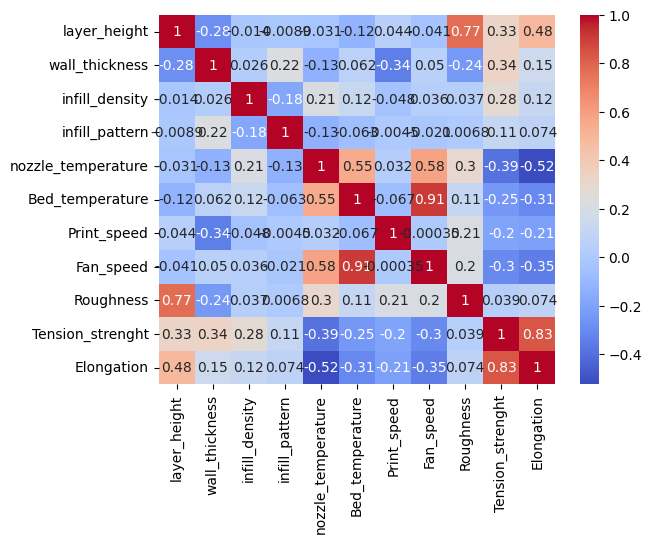

In [5]:
scaler=StandardScaler()
num_df = df.select_dtypes(include='number')
scaled_data=scaler.fit_transform(num_df)
scaled_df = pd.DataFrame(
    scaled_data,
    columns=num_df.columns
)
correlation_matrix=scaled_df.corr()
sns.heatmap(correlation_matrix,annot=True, cmap="coolwarm")
plt.show()


In [6]:
scaled_df

,layer_height,wall_thickness,infill_density,infill_pattern,nozzle_temperature,Bed_temperature,Print_speed,Fan_speed,Roughness,Tension_strenght,Elongation
0,-1.258327,0.824664,1.290338,-1.030776,-0.151724,-1.208797,-0.854175,-1.364674,-1.427153,-0.192461,-0.561649
1,-1.258327,0.483424,1.290338,0.970143,0.182069,-0.626457,-0.854175,-0.661673,-1.353451,-0.411468,-0.297344
2,-1.258327,-1.564018,0.924521,-1.030776,0.515863,-0.044117,-0.854175,0.041328,-1.269219,-1.287496,-1.090261
3,-1.258327,-0.540297,0.558703,0.970143,1.183449,0.538224,-0.854175,0.744329,-0.974408,-1.068489,-1.486719
4,-1.258327,0.142183,1.290338,-1.030776,1.851036,1.120564,-0.854175,1.447330,-0.721713,-1.616006,-1.222413
...,...,...,...,...,...,...,...,...,...,...,...
61,-0.614532,1.165904,-1.636202,0.970143,-1.486898,0.538224,0.555214,0.744329,0.415416,-1.177992,-0.958108
62,-0.936429,-1.222778,0.924521,-1.030776,0.515863,-0.044117,-0.854175,0.041328,-1.269219,-0.849482,-1.090261
63,-1.258327,-0.369677,0.558703,0.970143,1.183449,1.702904,-0.854175,0.744329,-0.974408,-1.068489,-1.090261
64,-0.775481,0.142183,-1.636202,0.970143,1.517243,0.538224,0.731387,0.744329,0.468060,-1.616006,-1.486719


Model Training

In [7]:
from sklearn.model_selection import train_test_split
X=scaled_df.drop("Roughness",axis=1)
y=scaled_df["Roughness"]

In [8]:
X_train,X_test,y_train,y_test=train_test_split(X,y, test_size=0.2, random_state=42)
model=RandomForestRegressor()
model.fit(X_train,y_train)

RandomForestRegressor()

In [9]:
Y_predict=model.predict(X_test)

Error Estimation

In [10]:
print(f"mean_squared_error: {mean_squared_error(y_test,Y_predict)}")

mean_squared_error: 0.15608942638339024


In [11]:
print(f"r2_score: {r2_score(y_test,Y_predict)}")

r2_score: 0.8514997358430665


Metric 1: Mean Absolute Error (MAE)This tells you, on average, how many microns ($\mu m$) your model is off by.Interpretation: "My model predicts surface roughness with an average error of $\pm 12 \mu m$."

Metric 2: $R^2$ Score (Coefficient of Determination)This ranges from 0 to 1. It tells you how much of the "physics" your model captured.1.0: Perfect model.0.8 - 0.9: Excellent for manufacturing research.< 0.5: Your model is missing a key variable (maybe you forgot to include 'Material Type'?).

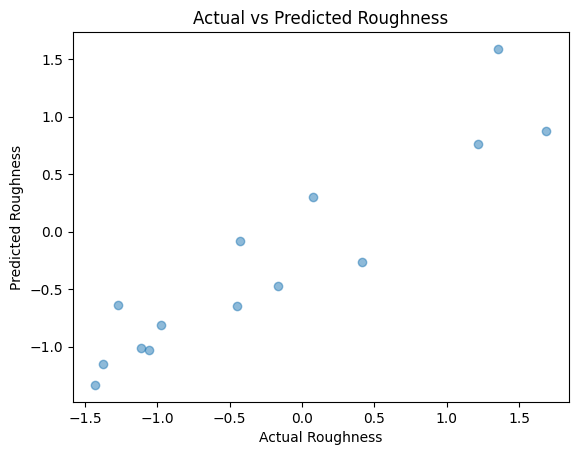

In [12]:
plt.scatter(y_test,Y_predict, alpha=0.5)
plt.xlabel("Actual Roughness")
plt.ylabel("Predicted Roughness")
plt.title("Actual vs Predicted Roughness")
plt.show()


Finding Important Feature

In [13]:
importances = model.feature_importances_
feature_names = X.columns
feature_df=pd.DataFrame({"Feature": feature_names, "Importance": importances})
feature_df=feature_df.sort_values(by="Importance", ascending=True)

Text(0, 0.5, 'Feature')

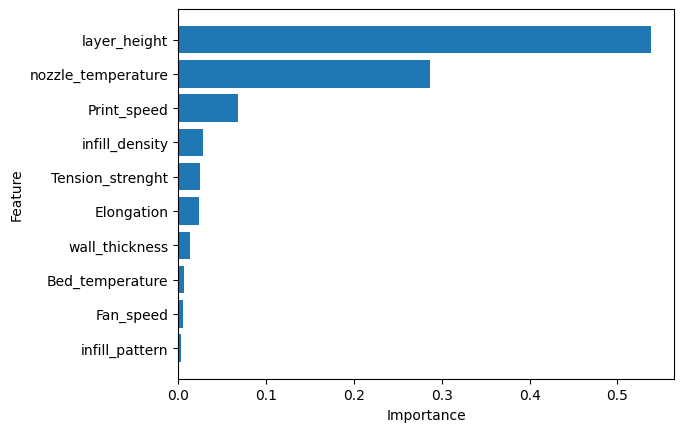

In [14]:
plt.barh(feature_df["Feature"], feature_df["Importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")